# Blood Lab Analysis

For the purposes of this project, the blood labs that could contribute to metabolism and metabolic syndrome will be analyzed. The blood labs of focus are as follows:

 * Cholesterol panel
 * CBC with differential
 * Glycohemoglobin (hemoglobin A1c)
 * Insulin
 * Fasting glucose
 * Sex hormones

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import scipy.stats as stats
from math import erf, sqrt
from math import atanh, sqrt

In [2]:
os.getcwd()

'C:\\Users\\chungs4\\Documents\\GitHub\\portfolio_ds_projects\\NHANES_analysis'

## Lipid Panel

Results are given in milligrams per deciliter (mg/dL). Here are the ranges for total cholesterol in adults:

* Normal: Less than 200 mg/dL
* Borderline high: 200 to 239 mg/dL
* High: At or above 240 mg/dL
* These are the adult ranges for LDL cholesterol:

LDL Range:

* Optimal: Less than 100 mg/dL (This is the goal for people with diabetes or heart disease.)
* Near optimal: 100 to 129 mg/dL
* Borderline high: 130 to 159 mg/dL
* High: 160 to 189 mg/dL
* Very high: 190 mg/dL and higher

High levels of triglycerides are linked with a higher heart disease risk. Here are the adult ranges:

* Normal: Less than 150 mg/dL
* Borderline high: 150 to 199 mg/dL
* High: 200 to 499 mg/dL
* Very high: Above 500 mg/dL (https://www.hopkinsmedicine.org/health/treatment-tests-and-therapies/lipid-panel)



In [3]:
df_ldl = pd.read_csv('tri_ldl_cleaned.csv')
df_hdl = pd.read_csv('hdl_cleaned.csv')
df_total = pd.read_csv('total_chol_cleaned.csv')
df_a = pd.read_csv('cleaned_anthropometry.csv')
df_d = pd.read_csv('cleaned_demographics.csv')

In [4]:
df = df_d.merge(df_a, on='participant_id')

In [5]:
df.head()

,participant_id,gender,age_year,race,education_level,marital_status,family_income_poverty,weight_kg,weight_comment,recumbent_length_cm,standing_height,standing_height_comment,bmi,bmi_category_child,upper_leg_cm,upper_arm_cm,arm_circumference_cm,waist_circ_cm,hip_circ_cm
0,109264.0,2.0,13.0,1.0,NaN,NaN,0.83,42.2,NaN,NaN,154.7,NaN,17.6,2.0,36.3,33.8,22.7,63.8,85.0
1,109265.0,1.0,2.0,3.0,NaN,NaN,3.06,12.0,NaN,91.6,89.3,NaN,15.0,2.0,NaN,18.6,14.8,41.2,NaN
2,109266.0,2.0,29.0,6.0,5.0,3.0,5.00,97.1,NaN,NaN,160.2,NaN,37.8,NaN,40.8,34.7,35.8,117.9,126.1
3,109269.0,1.0,2.0,2.0,NaN,NaN,0.96,13.6,NaN,90.9,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,109270.0,2.0,11.0,4.0,NaN,NaN,1.88,75.3,NaN,NaN,156.0,NaN,30.9,4.0,42.6,36.1,31.0,91.4,NaN


In [6]:
df.columns

Index(['participant_id', 'gender', 'age_year', 'race', 'education_level',
       'marital_status', 'family_income_poverty', 'weight_kg',
       'weight_comment', 'recumbent_length_cm', 'standing_height',
       'standing_height_comment', 'bmi', 'bmi_category_child', 'upper_leg_cm',
       'upper_arm_cm', 'arm_circumference_cm', 'waist_circ_cm', 'hip_circ_cm'],
      dtype='object')

In [7]:
df = df[['participant_id', 'gender', 'age_year', 'race', 'bmi']]

In [8]:
df_c = df.merge(df_ldl, on='participant_id')

In [9]:
df_c.head()

,participant_id,gender,age_year,race,bmi,Unnamed: 0,triglyceride_mg_dl,triglyceride_mmol_l,ldl_friedewald_mg_dl,ldl_friedwalkd_mmol_l,ldl_martin_hopkins_mg_dl,ldl_martin_hopkins_mmol_l,ldl_nih_mg_dl,ldl_nih_mmol_l
0,109264.0,2.0,13.0,1.0,17.6,0,40.0,0.452,86.0,2.224,82.0,2.121,85.0,2.198
1,109271.0,1.0,49.0,3.0,29.7,1,84.0,0.948,97.0,2.508,96.0,2.483,98.0,2.534
2,109274.0,1.0,68.0,7.0,30.2,2,133.0,1.502,49.0,1.267,54.0,1.396,52.0,1.345
3,109277.0,2.0,12.0,1.0,18.6,3,24.0,0.271,64.0,1.655,62.0,1.603,61.0,1.577
4,109282.0,1.0,76.0,3.0,26.6,4,132.0,1.490,164.0,4.241,163.0,4.215,166.0,4.293


In [10]:
df_c.columns

Index(['participant_id', 'gender', 'age_year', 'race', 'bmi', 'Unnamed: 0',
       'triglyceride_mg_dl', 'triglyceride_mmol_l', 'ldl_friedewald_mg_dl',
       'ldl_friedwalkd_mmol_l', 'ldl_martin_hopkins_mg_dl',
       'ldl_martin_hopkins_mmol_l', 'ldl_nih_mg_dl', 'ldl_nih_mmol_l'],
      dtype='object')

In [11]:
df_c = df_c.drop('Unnamed: 0', axis =1)

In [12]:
df_c = df_c.merge(df_hdl, on='participant_id')

In [13]:
df_c.columns

Index(['participant_id', 'gender', 'age_year', 'race', 'bmi',
       'triglyceride_mg_dl', 'triglyceride_mmol_l', 'ldl_friedewald_mg_dl',
       'ldl_friedwalkd_mmol_l', 'ldl_martin_hopkins_mg_dl',
       'ldl_martin_hopkins_mmol_l', 'ldl_nih_mg_dl', 'ldl_nih_mmol_l',
       'Unnamed: 0', 'direct_hdl_mg_dl', 'direct_hdl_mmol_l'],
      dtype='object')

In [14]:
df_c = df_c.drop('Unnamed: 0', axis =1)

In [15]:
df_c = df_c.merge(df_total, on='participant_id')

In [16]:
df_c.head()

,participant_id,gender,age_year,race,bmi,triglyceride_mg_dl,triglyceride_mmol_l,ldl_friedewald_mg_dl,ldl_friedwalkd_mmol_l,ldl_martin_hopkins_mg_dl,ldl_martin_hopkins_mmol_l,ldl_nih_mg_dl,ldl_nih_mmol_l,direct_hdl_mg_dl,direct_hdl_mmol_l,Unnamed: 0,total_cholesterol_mg_dl,total_cholesterol_mmol_l
0,109264.0,2.0,13.0,1.0,17.6,40.0,0.452,86.0,2.224,82.0,2.121,85.0,2.198,72.0,1.86,0,166.0,4.29
1,109271.0,1.0,49.0,3.0,29.7,84.0,0.948,97.0,2.508,96.0,2.483,98.0,2.534,33.0,0.85,3,147.0,3.80
2,109274.0,1.0,68.0,7.0,30.2,133.0,1.502,49.0,1.267,54.0,1.396,52.0,1.345,29.0,0.75,5,105.0,2.72
3,109277.0,2.0,12.0,1.0,18.6,24.0,0.271,64.0,1.655,62.0,1.603,61.0,1.577,60.0,1.55,7,129.0,3.34
4,109282.0,1.0,76.0,3.0,26.6,132.0,1.490,164.0,4.241,163.0,4.215,166.0,4.293,43.0,1.11,10,233.0,6.03


In [17]:
df_c.columns

Index(['participant_id', 'gender', 'age_year', 'race', 'bmi',
       'triglyceride_mg_dl', 'triglyceride_mmol_l', 'ldl_friedewald_mg_dl',
       'ldl_friedwalkd_mmol_l', 'ldl_martin_hopkins_mg_dl',
       'ldl_martin_hopkins_mmol_l', 'ldl_nih_mg_dl', 'ldl_nih_mmol_l',
       'direct_hdl_mg_dl', 'direct_hdl_mmol_l', 'Unnamed: 0',
       'total_cholesterol_mg_dl', 'total_cholesterol_mmol_l'],
      dtype='object')

In [18]:
df_c = df_c.drop('Unnamed: 0', axis =1)

In [19]:
df_c.shape

(4598, 17)

In [20]:
df_c = df_c[['participant_id', 'gender', 'age_year', 'race', 'bmi','triglyceride_mg_dl','ldl_friedewald_mg_dl','ldl_martin_hopkins_mg_dl','ldl_nih_mg_dl','direct_hdl_mg_dl','total_cholesterol_mg_dl']]

In [21]:
df_c.describe(include='all')

,participant_id,gender,age_year,race,bmi,triglyceride_mg_dl,ldl_friedewald_mg_dl,ldl_martin_hopkins_mg_dl,ldl_nih_mg_dl,direct_hdl_mg_dl,total_cholesterol_mg_dl
count,4598.000000,4598.000000,4598.000000,4598.000000,4579.000000,4587.000000,4554.000000,4554.000000,4579.000000,4598.000000,4598.000000
mean,117150.267073,1.511962,45.503045,3.473032,29.187071,103.844997,105.332016,105.612429,106.866783,53.568291,179.336668
std,4474.174276,0.499911,20.461658,1.634291,7.698785,90.250111,35.205992,35.190495,35.921206,15.477225,41.061987
min,109264.000000,1.000000,12.000000,1.000000,14.600000,10.000000,7.000000,14.000000,14.000000,11.000000,73.000000
25%,113303.500000,1.000000,27.000000,3.000000,23.950000,56.000000,81.000000,81.000000,81.000000,42.000000,151.000000
50%,117212.500000,2.000000,46.000000,3.000000,27.900000,84.000000,101.000000,102.000000,103.000000,51.000000,175.000000
75%,120987.750000,2.000000,62.000000,4.000000,33.000000,126.000000,126.000000,127.000000,128.000000,61.000000,203.000000
max,124822.000000,2.000000,80.000000,7.000000,92.300000,2684.000000,357.000000,358.000000,359.000000,187.000000,446.000000


In [22]:
df_c.isna().sum()

participant_id               0
gender                       0
age_year                     0
race                         0
bmi                         19
triglyceride_mg_dl          11
ldl_friedewald_mg_dl        44
ldl_martin_hopkins_mg_dl    44
ldl_nih_mg_dl               19
direct_hdl_mg_dl             0
total_cholesterol_mg_dl      0
dtype: int64

In [23]:
df_c = df_c.dropna(subset=['bmi'])

In [24]:
df_c.isna().sum()

participant_id               0
gender                       0
age_year                     0
race                         0
bmi                          0
triglyceride_mg_dl          11
ldl_friedewald_mg_dl        44
ldl_martin_hopkins_mg_dl    44
ldl_nih_mg_dl               19
direct_hdl_mg_dl             0
total_cholesterol_mg_dl      0
dtype: int64

The appropriate calculation for the LDL cholesterol will need to be sorted out to see which column and measurements are kept. What is the most commonly used calculation typically in hospitals?

For consistency, the same way the BMI outliers were removed will be used for the blood lab analysis as well.

In [25]:
num_high_bmi = (df_c['bmi'] >= 60).sum()
print(f"Number of subjects with BMI >= 60: {num_high_bmi}")
prop_high_bmi = (df_c['bmi'] >= 60).mean()
print(f"Proportion of subjects with BMI >= 60: {prop_high_bmi:.2%}")

Number of subjects with BMI >= 60: 19
Proportion of subjects with BMI >= 60: 0.41%


In [26]:
# Count number of subjects with 50 <= BMI < 60
num_bmi_50_60 = ((df_c['bmi'] >= 50) & (df_c['bmi'] < 60)).sum()
print(f"Number of subjects with BMI between 50 and 60: {num_bmi_50_60}")
prop_bmi_50_60 = ((df_c['bmi'] >= 50) & (df_c['bmi'] < 60)).mean()
print(f"Proportion of subjects with BMI between 50 and 60: {prop_bmi_50_60:.2%}")

Number of subjects with BMI between 50 and 60: 52
Proportion of subjects with BMI between 50 and 60: 1.14%


In [27]:
chol_filtered = df_c[df_c['bmi'] <= 50].copy()

In [28]:
df_adults = chol_filtered[chol_filtered['age_year'] >= 18]

In [29]:
df_adults.describe()

,participant_id,gender,age_year,race,bmi,triglyceride_mg_dl,ldl_friedewald_mg_dl,ldl_martin_hopkins_mg_dl,ldl_nih_mg_dl,direct_hdl_mg_dl,total_cholesterol_mg_dl
count,3971.000000,3971.000000,3971.000000,3971.000000,3971.000000,3960.000000,3929.000000,3929.000000,3952.000000,3971.000000,3971.000000
mean,117176.250315,1.511206,49.653991,3.473181,29.334827,108.463384,108.081191,108.589717,109.827935,53.900277,183.287837
std,4484.503563,0.499937,18.177217,1.623186,6.608189,94.239014,35.601877,35.432025,36.186407,15.914052,41.134111
min,109271.000000,1.000000,18.000000,1.000000,15.400000,10.000000,7.000000,14.000000,14.000000,11.000000,76.000000
25%,113365.000000,1.000000,34.000000,3.000000,24.600000,59.000000,84.000000,84.000000,85.000000,42.000000,155.000000
50%,117190.000000,2.000000,51.000000,3.000000,28.300000,88.000000,105.000000,105.000000,107.000000,51.000000,179.000000
75%,121075.500000,2.000000,64.000000,4.000000,33.200000,131.000000,129.000000,130.000000,132.000000,62.000000,208.000000
max,124822.000000,2.000000,80.000000,7.000000,49.900000,2684.000000,357.000000,358.000000,359.000000,187.000000,446.000000


### BMI vs Triglyceride

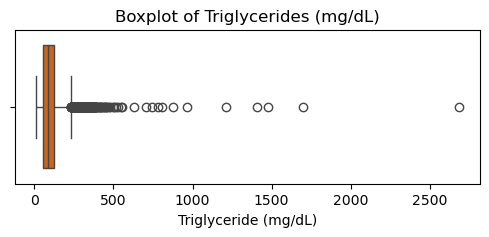

In [30]:
plt.figure(figsize=(6,2))
sns.boxplot(x=chol_filtered['triglyceride_mg_dl'], color='#E66100')
plt.title("Boxplot of Triglycerides (mg/dL)")
plt.xlabel("Triglyceride (mg/dL)")
plt.show()

75% quartile of the triglyceride level is 126 mg/dL in this dataset which is generally within normal limits. The concerning levels are when it goes above 200 mg/dL. The percentage of the values above 500 mg/dL should be assessed for removal to proceed with this analysis. Any value above 500 mg/dL is severely concerning.

In [31]:
# Define your threshold
threshold = 500  

# Count how many subjects exceed the threshold
extreme_count = (chol_filtered['triglyceride_mg_dl'] >= threshold).sum()

# Total number of subjects
total_count = chol_filtered['triglyceride_mg_dl'].notna().sum()

# Percentage
extreme_percent = (extreme_count / total_count) * 100

print(f"Subjects with extreme triglyceride values (≥ {threshold} µg/mL): {extreme_count}")
print(f"Total subjects with triglyceride values: {total_count}")
print(f"Percentage extreme: {extreme_percent:.2f}%")

Subjects with extreme triglyceride values (≥ 500 µg/mL): 17
Total subjects with triglyceride values: 4497
Percentage extreme: 0.38%


In [32]:
# Keep only subjects below threshold
chol_clean = chol_filtered[chol_filtered['triglyceride_mg_dl'] < threshold].copy()

print(f"Original: {chol_filtered.shape[0]} rows")
print(f"After removing extreme albumin values: {chol_clean.shape[0]} rows")

Original: 4508 rows
After removing extreme albumin values: 4480 rows


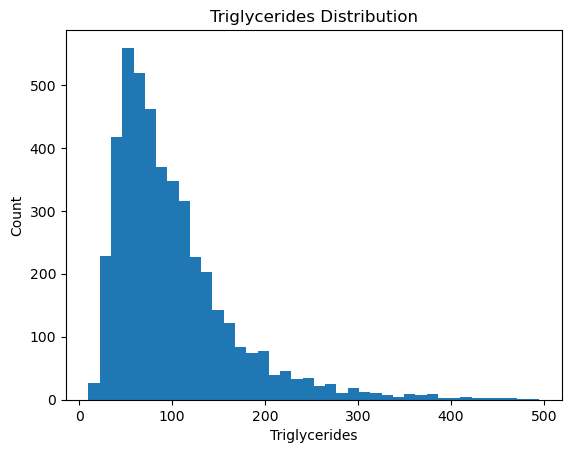

In [33]:
plt.hist(chol_clean['triglyceride_mg_dl'], bins=40)
plt.title("Triglycerides Distribution")
plt.xlabel("Triglycerides")
plt.ylabel("Count")
plt.show()

Triglyceride values seems to be noticeably right skewed. The datset will have to be normalized before applying regression models.

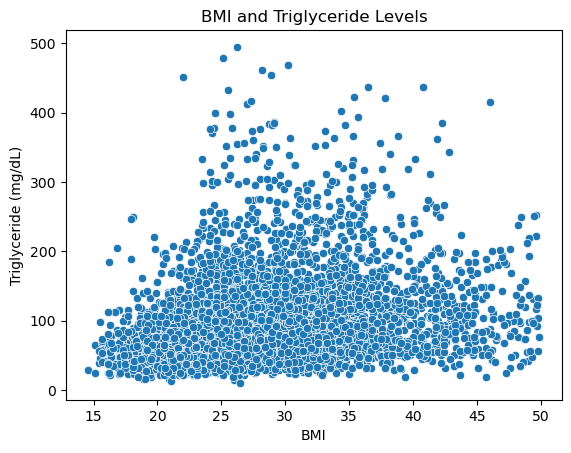

In [34]:
sns.scatterplot(x='bmi',y='triglyceride_mg_dl',data=chol_clean)
plt.xlabel('BMI')
plt.ylabel('Triglyceride (mg/dL)')
plt.title('BMI and Triglyceride Levels')
plt.show()

Triglyceride levels are generally higher between 25-35 ish range. 

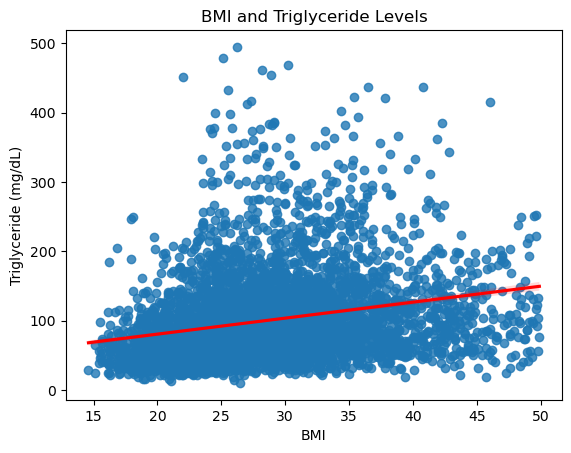

In [35]:
sns.regplot(x='bmi',y='triglyceride_mg_dl',data=chol_clean,line_kws={"color": "red"})
plt.xlabel('BMI')
plt.ylabel('Triglyceride (mg/dL)')
plt.title('BMI and Triglyceride Levels')
plt.show()

Slight increase in triglyceride level with increased BMI. When plotted separately within the population of obese people, however, there's no overt correlation.

I should also be comparing people with normal BMI with the urine labs too. 

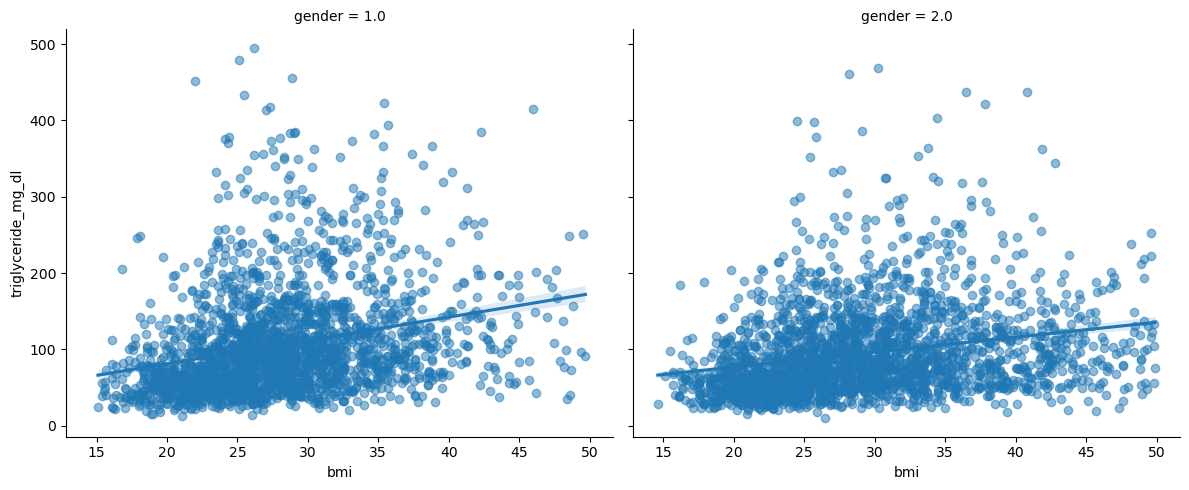

In [36]:
sns.lmplot(
    x="bmi",
    y="triglyceride_mg_dl",
    col="gender",
    data=chol_clean,
    height=5,
    aspect=1.2,
    scatter_kws={"alpha":0.5}  # optional: make points semi-transparent
)
plt.show()

When separated by sex, the male cohort appears to have a higher slope in the regression line. Now the data will be transformed with natural log to normalize the distribution.

### Log Transformation of Triglycerides

In [37]:
chol_clean['log_trig'] = np.log(chol_clean['triglyceride_mg_dl'])

In [38]:
chol_clean[['triglyceride_mg_dl', 'log_trig']].describe()

,triglyceride_mg_dl,log_trig
count,4480.000000,4480.000000
mean,100.544643,4.439393
std,64.338413,0.580103
min,10.000000,2.302585
25%,56.000000,4.025352
50%,83.000000,4.418841
75%,125.000000,4.828314
max,495.000000,6.204558


In [39]:
chol_clean['triglyceride_mg_dl'].skew(), chol_clean['log_trig'].skew()

(np.float64(1.873439188748375), np.float64(0.12405899066670531))

In [40]:
chol_clean['triglyceride_mg_dl'].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

0.25     56.00
0.50     83.00
0.75    125.00
0.90    181.10
0.95    228.00
0.99    349.21
Name: triglyceride_mg_dl, dtype: float64

In [41]:
chol_clean['log_trig'].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

0.25    4.025352
0.50    4.418841
0.75    4.828314
0.90    5.199048
0.95    5.429346
0.99    5.855673
Name: log_trig, dtype: float64

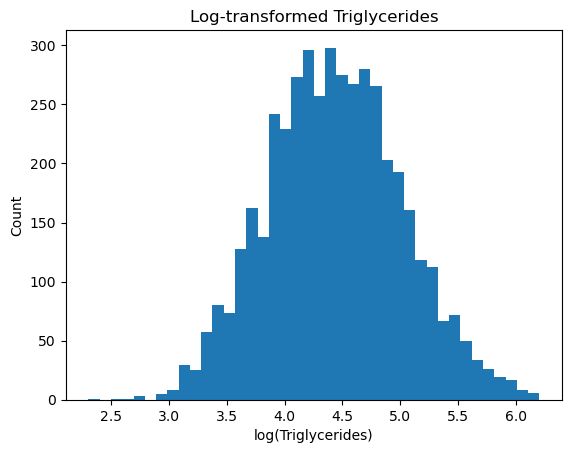

In [42]:
plt.hist(chol_clean['log_trig'], bins=40)
plt.title("Log-transformed Triglycerides")
plt.xlabel("log(Triglycerides)")
plt.ylabel("Count")
plt.show()

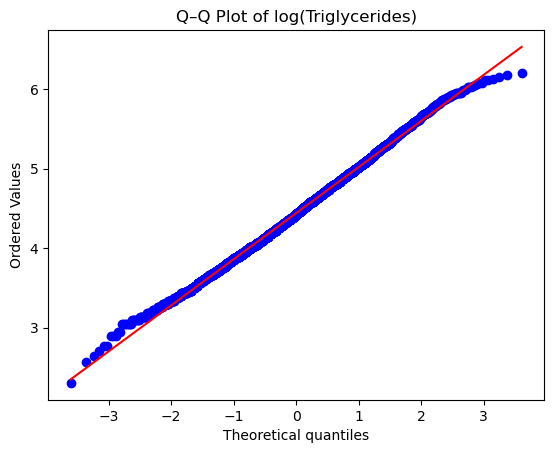

In [43]:
stats.probplot(chol_clean['log_trig'], dist="norm", plot=plt)
plt.title("Q–Q Plot of log(Triglycerides)")
plt.show()

In [44]:
chol_clean[['bmi','log_trig']].corr()

,bmi,log_trig
bmi,1.000000,0.289824
log_trig,0.289824,1.000000


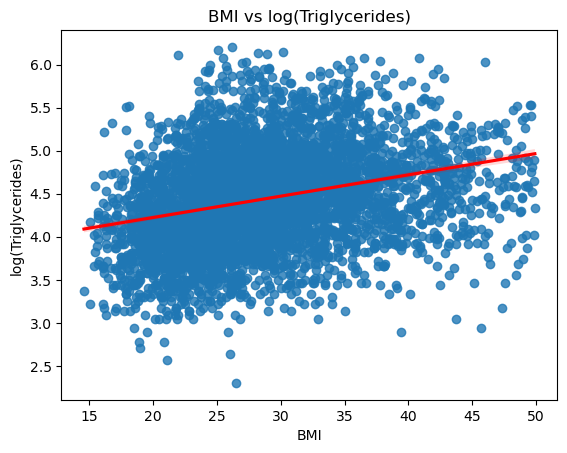

In [45]:
sns.regplot(x='bmi',y='log_trig',data=chol_clean,line_kws={"color": "red"})
plt.xlabel("BMI")
plt.ylabel("log(Triglycerides)")
plt.title("BMI vs log(Triglycerides)")
plt.show()

Overall, there is a weak positive correlation between the BMI and triglyceride levels. 

C:\Users\chungs4\AppData\Local\Temp\ipykernel_28944\3711787007.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="gender", y="log_trig", data=chol_clean, palette="Set2")


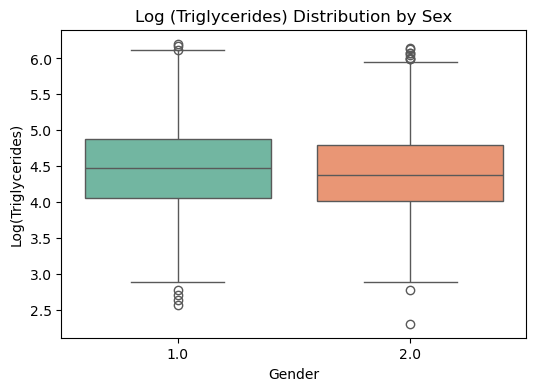

In [46]:
plt.figure(figsize=(6,4))
sns.boxplot(x="gender", y="log_trig", data=chol_clean, palette="Set2")
plt.title("Log (Triglycerides) Distribution by Sex")
plt.ylabel("Log(Triglycerides)")
plt.xlabel("Gender")
plt.show()

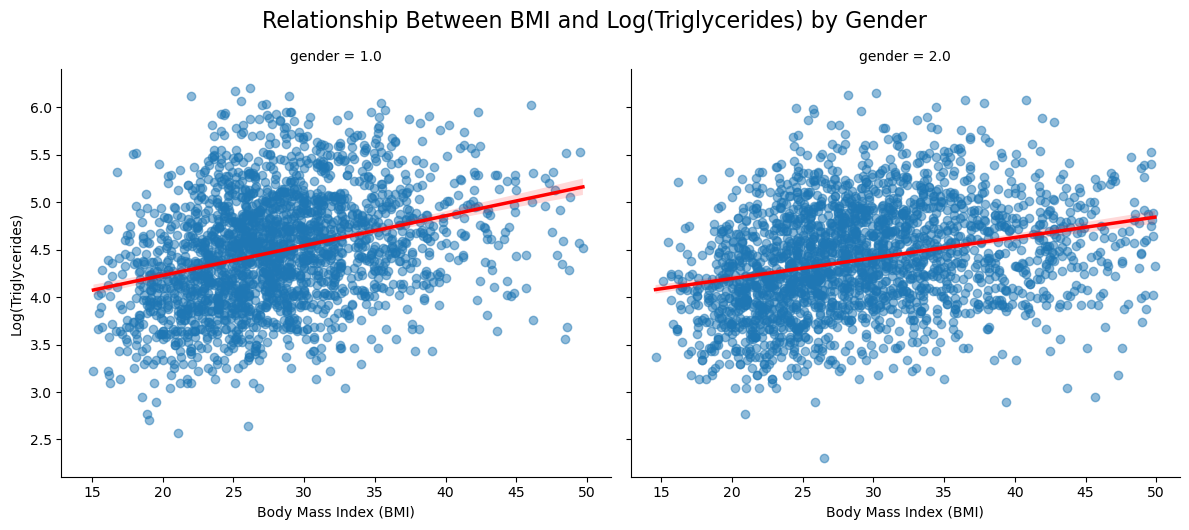

In [47]:
# Plot
g = sns.lmplot(
    x="bmi",
    y="log_trig",
    col="gender",  # use the new label column
    data=chol_clean,
    height=5,
    aspect=1.2,
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red", "linewidth": 2.5}
)

# Add an overall title
g.fig.suptitle("Relationship Between BMI and Log(Triglycerides) by Gender", fontsize=16, y=1.05)

# Add axis labels
g.set_axis_labels("Body Mass Index (BMI)", "Log(Triglycerides)")

plt.show()

In [48]:
for gender, df_group in chol_clean.groupby('gender'):
    corr_logtri = df_group[['bmi', 'log_trig']].corr().iloc[0, 1]
    print(f"Correlation between BMI and triglycerides for {gender}: {corr_logtri:.3f}")

Correlation between BMI and triglycerides for 1.0: 0.321
Correlation between BMI and triglycerides for 2.0: 0.283


When stratified by sex, the male cohort has a stronger correlation compared to the female cohort but they both show weak positive correlation.

### BMI vs Total Cholesterol

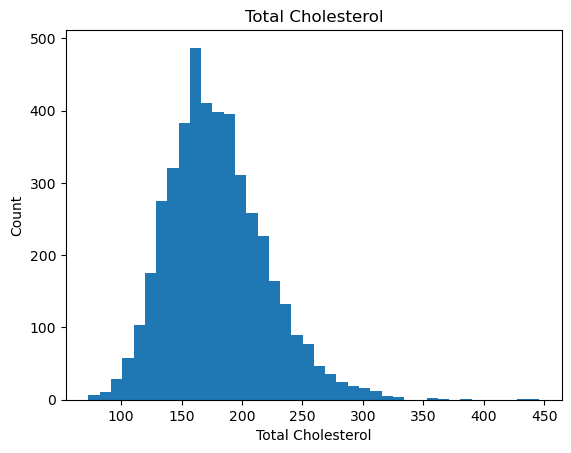

In [49]:
plt.hist(chol_clean['total_cholesterol_mg_dl'], bins=40)
plt.title("Total Cholesterol")
plt.xlabel("Total Cholesterol")
plt.ylabel("Count")
plt.show()

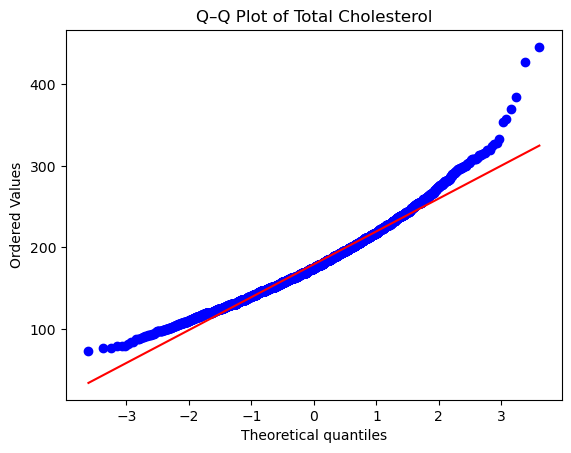

In [50]:
stats.probplot(chol_clean['total_cholesterol_mg_dl'], dist="norm", plot=plt)
plt.title("Q–Q Plot of Total Cholesterol")
plt.show()

In [51]:
chol_clean['total_cholesterol_mg_dl'].skew()

np.float64(0.7009388938900301)

The total cholesterol distribution is approximately normal, with a slight right skew but acceptable for regression. 

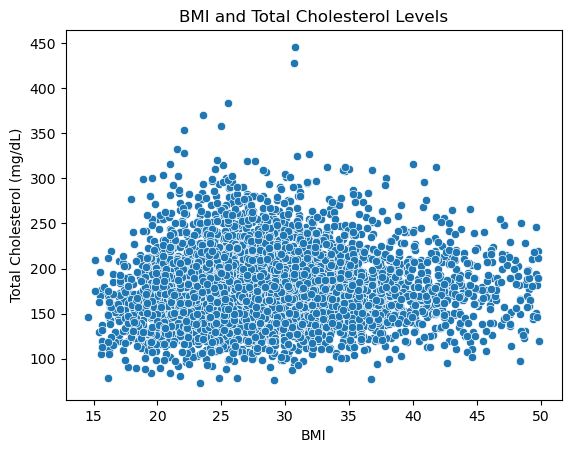

In [52]:
sns.scatterplot(x='bmi',y='total_cholesterol_mg_dl',data=chol_clean)
plt.xlabel('BMI')
plt.ylabel('Total Cholesterol (mg/dL)')
plt.title('BMI and Total Cholesterol Levels')
plt.show()

The total cholesterol values seem to be generally well clustered and only a few true outliers are seen. The decision was made to keep the outliers, as it would not impact the results of the analysis.

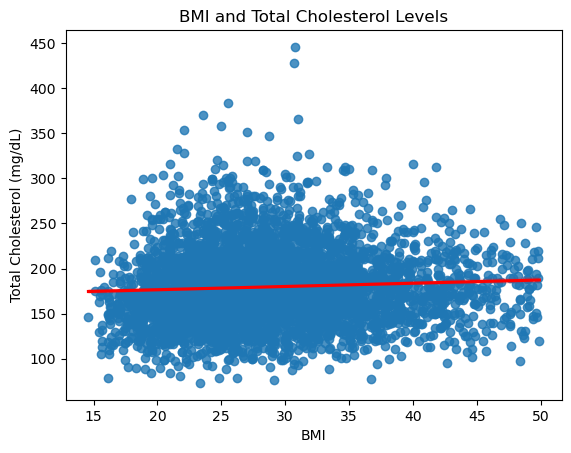

In [53]:
sns.regplot(x='bmi',y='total_cholesterol_mg_dl',data=chol_filtered,line_kws={"color": "red"})
plt.xlabel('BMI')
plt.ylabel('Total Cholesterol (mg/dL)')
plt.title('BMI and Total Cholesterol Levels')
plt.show()

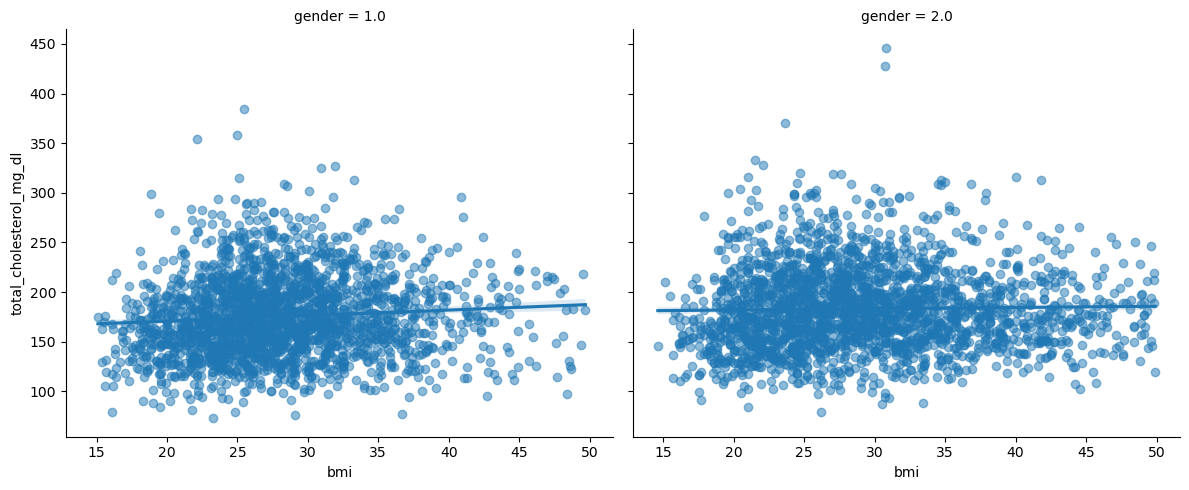

In [54]:
sns.lmplot(
    x="bmi",
    y="total_cholesterol_mg_dl",
    col="gender",
    data=chol_clean,
    height=5,
    aspect=1.2,
    scatter_kws={"alpha":0.5}  # optional: make points semi-transparent
)
plt.show()

In [55]:
chol_clean[['bmi','total_cholesterol_mg_dl']].corr()

,bmi,total_cholesterol_mg_dl
bmi,1.000000,0.057334
total_cholesterol_mg_dl,0.057334,1.000000


In [56]:
for gender, df_group in chol_clean.groupby('gender'):
    corr_totchol = df_group[['bmi', 'total_cholesterol_mg_dl']].corr().iloc[0, 1]
    print(f"Correlation between BMI and total cholesterol for {gender}: {corr_totchol:.3f}")

Correlation between BMI and total cholesterol for 1.0: 0.085
Correlation between BMI and total cholesterol for 2.0: 0.022


The overall total cholesterol level does not seem to have a significant correlation with BMI. When stratified, the male cohort seems to have a slightly higher correlation but still not significant enough. 

### Log Transformation of Total Cholesterol

In [57]:
chol_clean['log_totchol'] = np.log(chol_clean['total_cholesterol_mg_dl'])

In [58]:
chol_clean[['total_cholesterol_mg_dl', 'log_totchol']].describe()

,total_cholesterol_mg_dl,log_totchol
count,4480.000000,4480.000000
mean,179.309375,5.163693
std,40.843439,0.226006
min,73.000000,4.290459
25%,151.000000,5.017280
50%,175.000000,5.164786
75%,203.000000,5.313206
max,446.000000,6.100319


In [59]:
chol_clean['total_cholesterol_mg_dl'].skew(), chol_clean['log_totchol'].skew()

(np.float64(0.7009388938900301), np.float64(-0.07175330078266212))

In [60]:
chol_clean['total_cholesterol_mg_dl'].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

0.25    151.0
0.50    175.0
0.75    203.0
0.90    233.0
0.95    253.0
0.99    296.0
Name: total_cholesterol_mg_dl, dtype: float64

In [61]:
chol_clean['log_totchol'].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

0.25    5.017280
0.50    5.164786
0.75    5.313206
0.90    5.451038
0.95    5.533389
0.99    5.690359
Name: log_totchol, dtype: float64

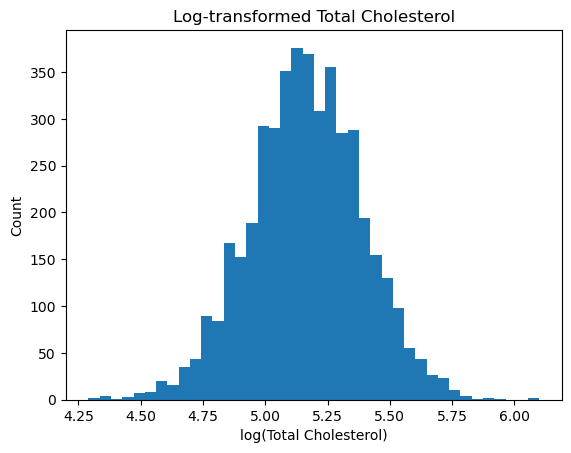

In [62]:
plt.hist(chol_clean['log_totchol'], bins=40)
plt.title("Log-transformed Total Cholesterol")
plt.xlabel("log(Total Cholesterol)")
plt.ylabel("Count")
plt.show()

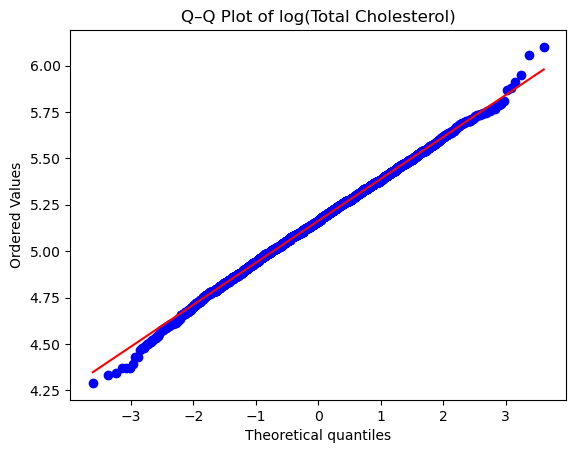

In [63]:
stats.probplot(chol_clean['log_totchol'], dist="norm", plot=plt)
plt.title("Q–Q Plot of log(Total Cholesterol)")
plt.show()

In [64]:
chol_clean[['bmi','log_totchol']].corr()

,bmi,log_totchol
bmi,1.00000,0.06704
log_totchol,0.06704,1.00000


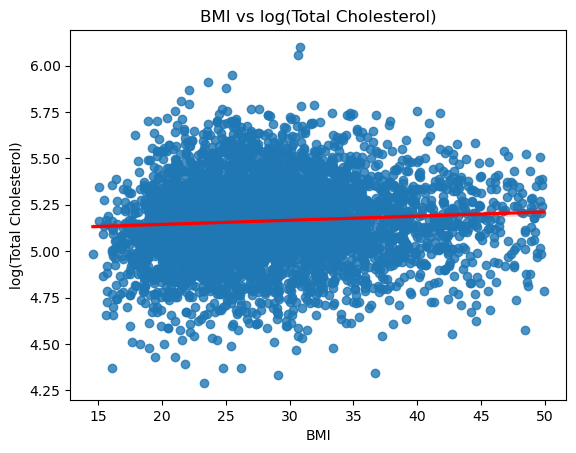

In [65]:
sns.regplot(x='bmi',y='log_totchol',data=chol_clean,line_kws={"color": "red"})
plt.xlabel("BMI")
plt.ylabel("log(Total Cholesterol)")
plt.title("BMI vs log(Total Cholesterol)")
plt.show()

C:\Users\chungs4\AppData\Local\Temp\ipykernel_28944\966328433.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="gender", y="log_totchol", data=chol_clean, palette="Set2")


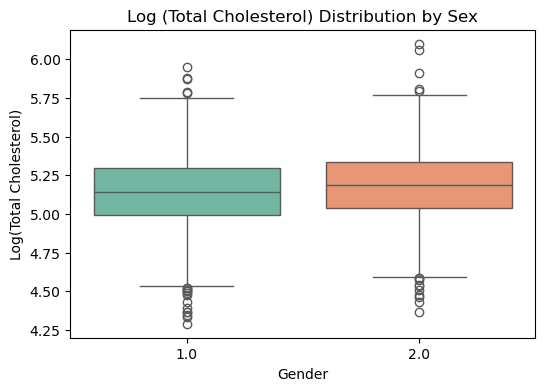

In [66]:
plt.figure(figsize=(6,4))
sns.boxplot(x="gender", y="log_totchol", data=chol_clean, palette="Set2")
plt.title("Log (Total Cholesterol) Distribution by Sex")
plt.ylabel("Log(Total Cholesterol)")
plt.xlabel("Gender")
plt.show()

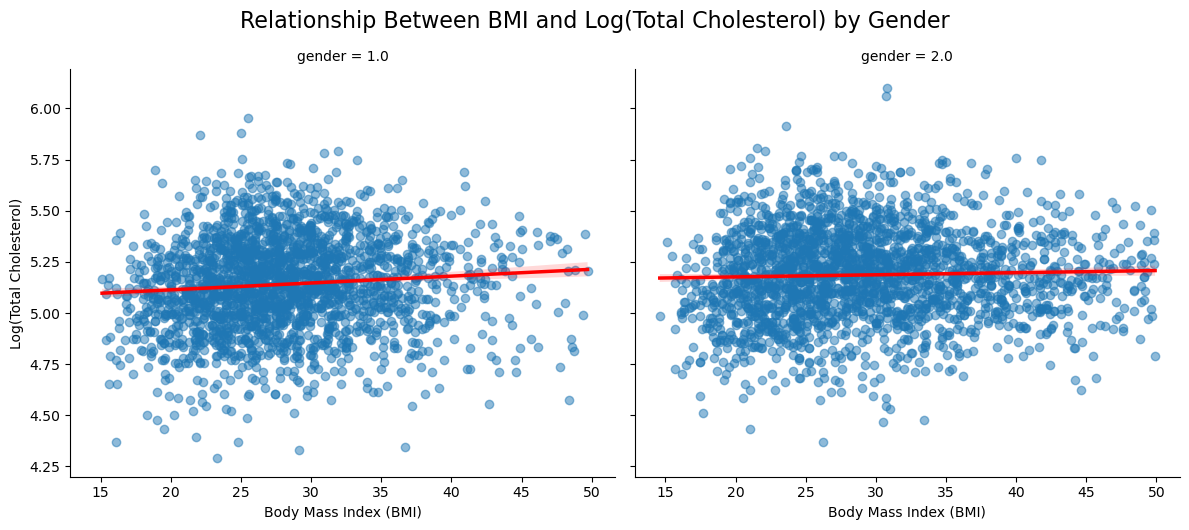

In [67]:
# Plot
g = sns.lmplot(
    x="bmi",
    y="log_totchol",
    col="gender",  # use the new label column
    data=chol_clean,
    height=5,
    aspect=1.2,
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red", "linewidth": 2.5}
)

# Add an overall title
g.fig.suptitle("Relationship Between BMI and Log(Total Cholesterol) by Gender", fontsize=16, y=1.05)

# Add axis labels
g.set_axis_labels("Body Mass Index (BMI)", "Log(Total Cholesterol)")

plt.show()

In [68]:
for gender, df_group in chol_clean.groupby('gender'):
    corr_logtot = df_group[['bmi', 'log_totchol']].corr().iloc[0, 1]
    print(f"Correlation between BMI and total cholesterol for {gender}: {corr_logtot:.3f}")

Correlation between BMI and total cholesterol for 1.0: 0.089
Correlation between BMI and total cholesterol for 2.0: 0.034


There is no significant difference between the two analyses, whether the data is transformed with natural log or not. Which makes sense, as the original distribution was pretty normally distributed to begin with. 

### BMI and LDL

There are three different ways to calculate the LDL: Friedwald, Martin-Hopkins, and NIH. 

Friedwald equation is what was traditionally used to calculate the LDL. However, there are more accurate and customizable method of calculating for the LDL which is the Martin-Hopkins method. (Martin SS, Blaha MJ, Elshazly MB, et al. Comparison of a novel method vs the Friedewald equation for estimating low-density lipoprotein cholesterol levels from the standard lipid profile. JAMA. 2013;310:2061-2068.) NIH method also does provide a more accurate result compared to the Friedwald equation. (Martins J, Steyn N, Rossouw HM, et alBest practice for LDL-cholesterol: when and how to calculateJournal of Clinical Pathology 2023;76:145-152.) 

The decision was made to use the Martin-Hopkins method, since this equation seems to provide a generally accurate result and comparable to NIH equation. 

In [69]:
chol_clean.columns

Index(['participant_id', 'gender', 'age_year', 'race', 'bmi',
       'triglyceride_mg_dl', 'ldl_friedewald_mg_dl',
       'ldl_martin_hopkins_mg_dl', 'ldl_nih_mg_dl', 'direct_hdl_mg_dl',
       'total_cholesterol_mg_dl', 'log_trig', 'log_totchol'],
      dtype='object')

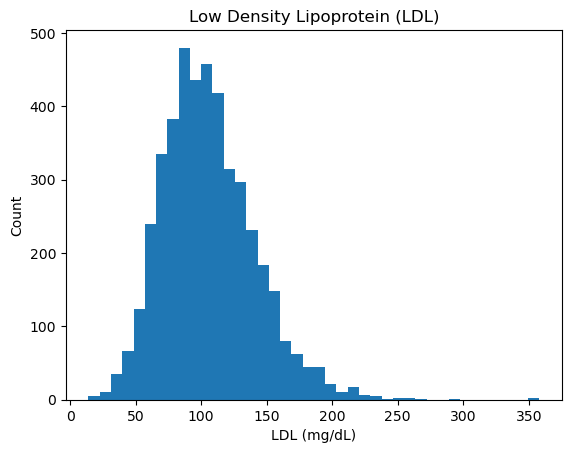

In [70]:
plt.hist(chol_clean['ldl_martin_hopkins_mg_dl'], bins=40)
plt.title("Low Density Lipoprotein (LDL)")
plt.xlabel("LDL (mg/dL)")
plt.ylabel("Count")
plt.show()

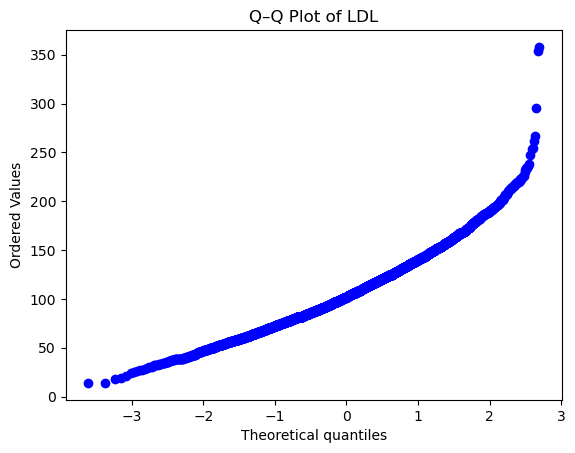

In [71]:
stats.probplot(chol_clean['ldl_martin_hopkins_mg_dl'], dist="norm", plot=plt)
plt.title("Q–Q Plot of LDL")
plt.show()

In [72]:
chol_clean['ldl_martin_hopkins_mg_dl'].skew()

np.float64(0.7747193100562147)

Like the total cholesterol, the data is pretty normally distributed and acceptable for use with regression. 

Text(0.5, 1.0, 'Regression Plot')

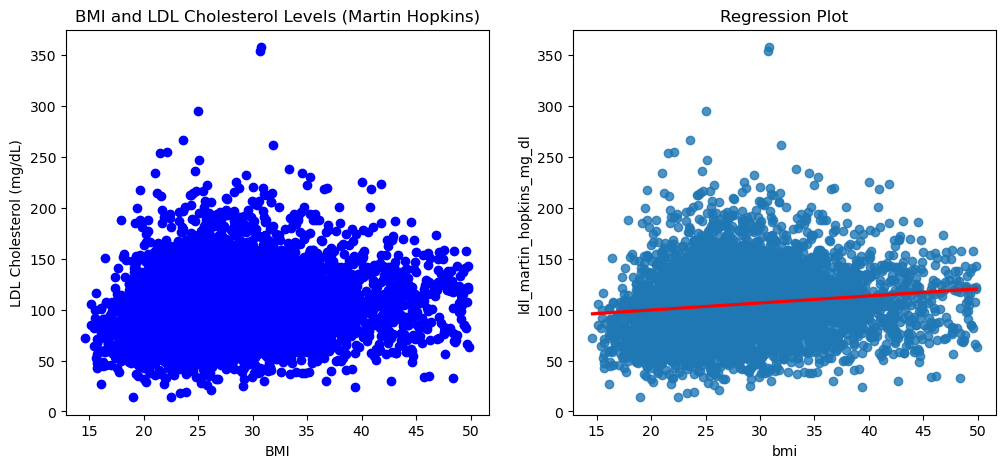

In [73]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter plot
axes[0].scatter(chol_clean['bmi'], chol_clean['ldl_martin_hopkins_mg_dl'], color='blue')
axes[0].set_title('BMI and LDL Cholesterol Levels (Martin Hopkins)')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('LDL Cholesterol (mg/dL)')

# Regression plot (using seaborn)
sns.regplot(x='bmi',y='ldl_martin_hopkins_mg_dl',data=chol_clean, ax=axes[1],line_kws={"color": "red"})
axes[1].set_title('Regression Plot')

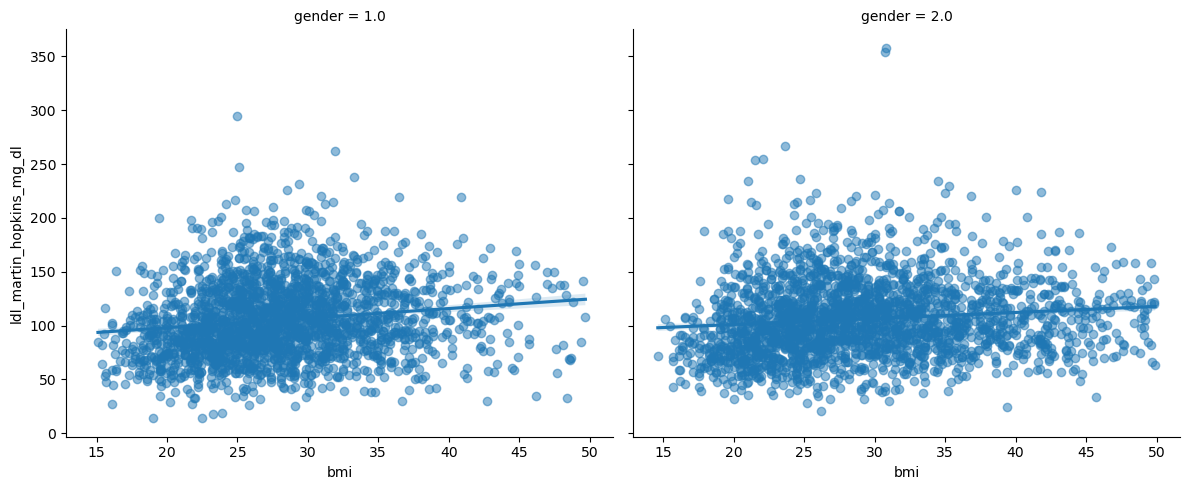

In [74]:
sns.lmplot(
    x="bmi",
    y="ldl_martin_hopkins_mg_dl",
    col="gender",
    data=chol_clean,
    height=5,
    aspect=1.2,
    scatter_kws={"alpha":0.5}  # optional: make points semi-transparent
)
plt.show()

In [75]:
chol_clean[['bmi','ldl_martin_hopkins_mg_dl']].corr()

,bmi,ldl_martin_hopkins_mg_dl
bmi,1.000000,0.133122
ldl_martin_hopkins_mg_dl,0.133122,1.000000


In [76]:
for gender, df_group in chol_clean.groupby('gender'):
    corr_ldl = df_group[['bmi', 'ldl_martin_hopkins_mg_dl']].corr().iloc[0, 1]
    print(f"Correlation between BMI and LDL for {gender}: {corr_ldl:.3f}")

Correlation between BMI and LDL for 1.0: 0.154
Correlation between BMI and LDL for 2.0: 0.116


LDL and BMI do not seem to have a significant correlation. The correlation slightly increases with the sex but overall the relationship is weak. 

### BMI and HDL

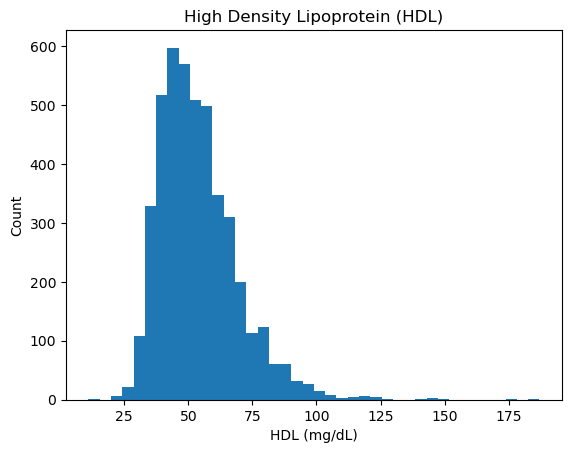

In [77]:
plt.hist(chol_clean['direct_hdl_mg_dl'], bins=40)
plt.title("High Density Lipoprotein (HDL)")
plt.xlabel("HDL (mg/dL)")
plt.ylabel("Count")
plt.show()

In [78]:
chol_clean['direct_hdl_mg_dl'].skew()

np.float64(1.404456478129869)

There is a slight right skew with HDL lab values. The HDL will be transformed using natural log for regression.

In [79]:
chol_clean[['bmi','ldl_martin_hopkins_mg_dl']].corr()

,bmi,ldl_martin_hopkins_mg_dl
bmi,1.000000,0.133122
ldl_martin_hopkins_mg_dl,0.133122,1.000000


Text(0.5, 1.0, 'Regression Plot')

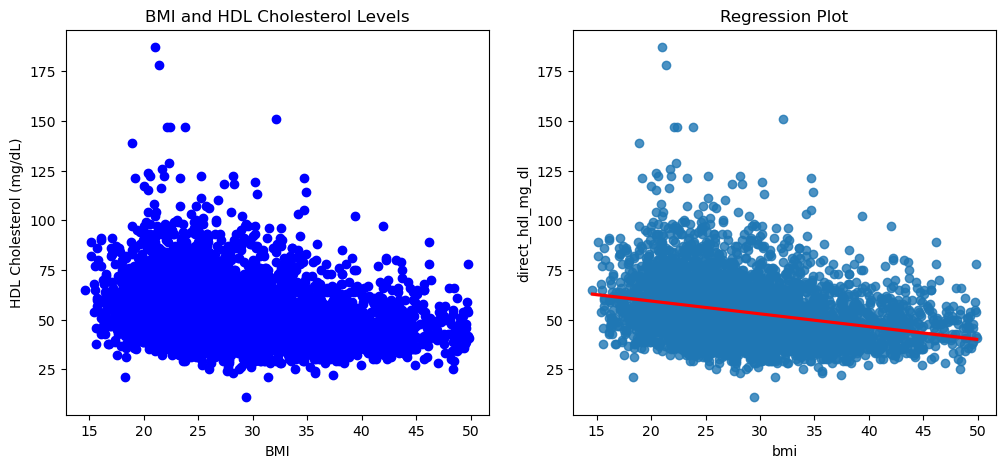

In [80]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter plot
axes[0].scatter(chol_clean['bmi'], chol_clean['direct_hdl_mg_dl'], color='blue')
axes[0].set_title('BMI and HDL Cholesterol Levels')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('HDL Cholesterol (mg/dL)')

# Regression plot (using seaborn)
sns.regplot(x='bmi',y='direct_hdl_mg_dl',data=chol_clean, ax=axes[1],line_kws={"color": "red"})
axes[1].set_title('Regression Plot')

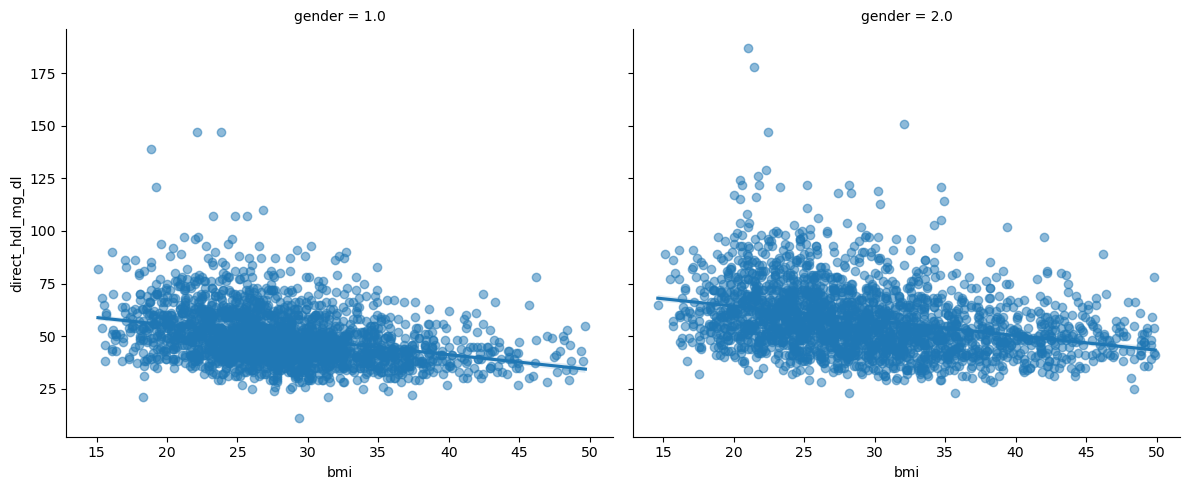

In [81]:
sns.lmplot(
    x="bmi",
    y="direct_hdl_mg_dl",
    col="gender",
    data=chol_clean,
    height=5,
    aspect=1.2,
    scatter_kws={"alpha":0.5}  # optional: make points semi-transparent
)
plt.show()

In [82]:
for gender, df_group in chol_clean.groupby('gender'):
    corr_hdl = df_group[['bmi', 'direct_hdl_mg_dl']].corr().iloc[0, 1]
    print(f"Correlation between BMI and direct HDL for {gender}: {corr_hdl:.3f}")

Correlation between BMI and direct HDL for 1.0: -0.327
Correlation between BMI and direct HDL for 2.0: -0.314


### Log Transformation of High-Density Lipoprotein (HDL)

In [83]:
chol_clean['log_hdl'] = np.log(chol_clean['direct_hdl_mg_dl'])

In [84]:
chol_clean[['direct_hdl_mg_dl', 'log_hdl']].describe()

,direct_hdl_mg_dl,log_hdl
count,4480.000000,4480.000000
mean,53.747991,3.947164
std,15.406645,0.269141
min,11.000000,2.397895
25%,43.000000,3.761200
50%,51.000000,3.931826
75%,62.000000,4.127134
max,187.000000,5.231109


In [85]:
chol_clean['log_hdl'].skew()

np.float64(0.2529529801572975)

In [86]:
chol_clean['direct_hdl_mg_dl'].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

0.25    43.00
0.50    51.00
0.75    62.00
0.90    73.00
0.95    82.00
0.99    99.21
Name: direct_hdl_mg_dl, dtype: float64

In [87]:
chol_clean['log_hdl'].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

0.25    3.761200
0.50    3.931826
0.75    4.127134
0.90    4.290459
0.95    4.406719
0.99    4.597230
Name: log_hdl, dtype: float64

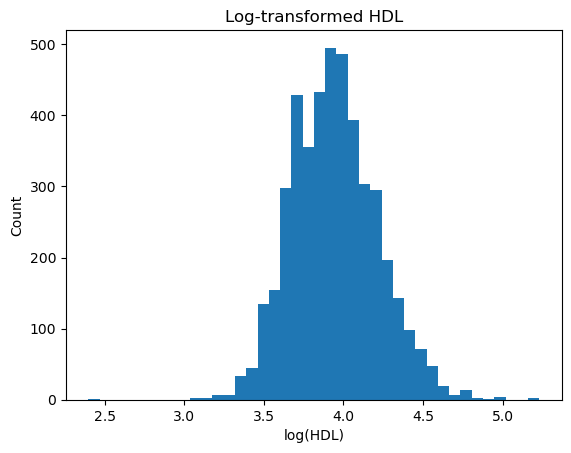

In [88]:
plt.hist(chol_clean['log_hdl'], bins=40)
plt.title("Log-transformed HDL")
plt.xlabel("log(HDL)")
plt.ylabel("Count")
plt.show()

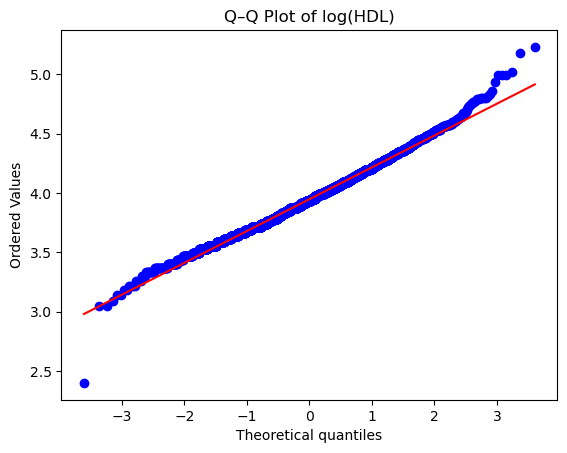

In [89]:
stats.probplot(chol_clean['log_hdl'], dist="norm", plot=plt)
plt.title("Q–Q Plot of log(HDL)")
plt.show()

In [90]:
chol_clean[['bmi','log_hdl']].corr()

,bmi,log_hdl
bmi,1.000000,-0.295443
log_hdl,-0.295443,1.000000


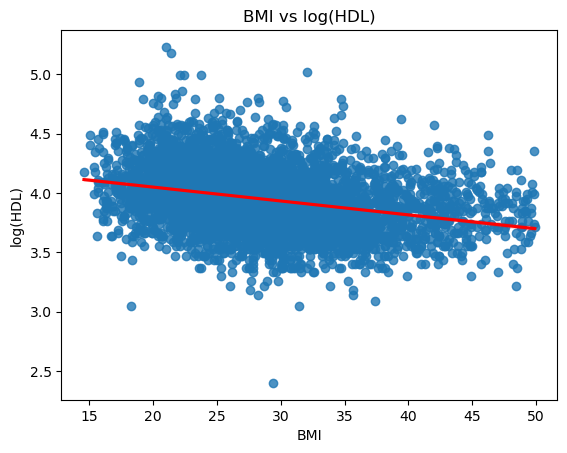

In [91]:
sns.regplot(x='bmi',y='log_hdl',data=chol_clean,line_kws={"color": "red"})
plt.xlabel("BMI")
plt.ylabel("log(HDL)")
plt.title("BMI vs log(HDL)")
plt.show()

C:\Users\chungs4\AppData\Local\Temp\ipykernel_28944\3378953594.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="gender", y="log_hdl", data=chol_clean, palette="Set2")


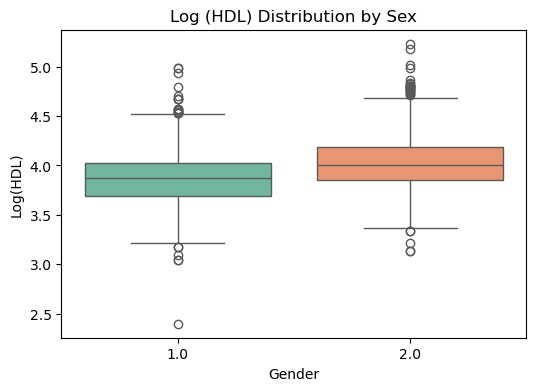

In [92]:
plt.figure(figsize=(6,4))
sns.boxplot(x="gender", y="log_hdl", data=chol_clean, palette="Set2")
plt.title("Log (HDL) Distribution by Sex")
plt.ylabel("Log(HDL)")
plt.xlabel("Gender")
plt.show()

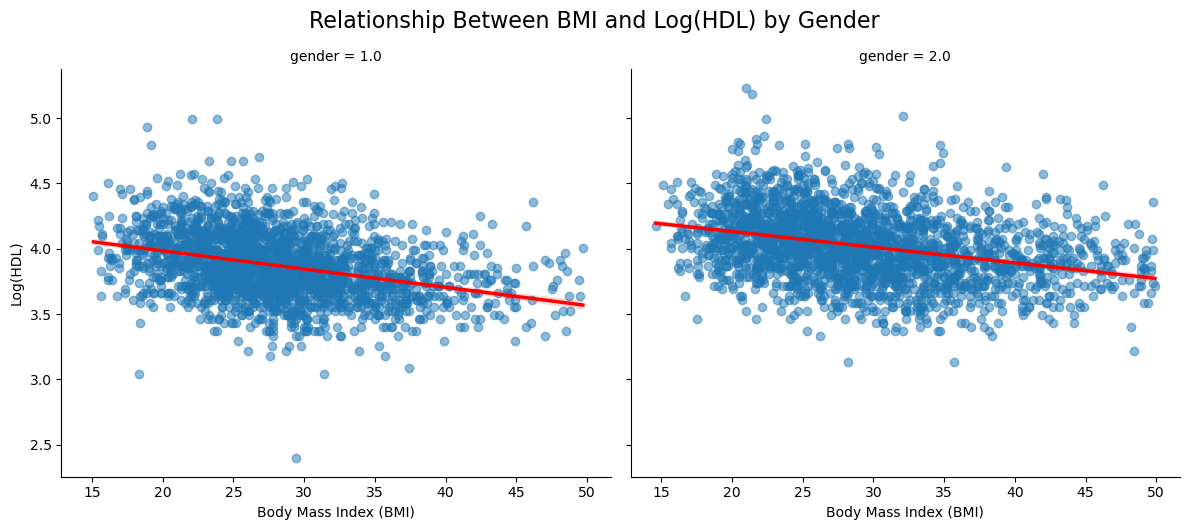

In [93]:
# Plot
g = sns.lmplot(
    x="bmi",
    y="log_hdl",
    col="gender",  # use the new label column
    data=chol_clean,
    height=5,
    aspect=1.2,
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red", "linewidth": 2.5}
)

# Add an overall title
g.fig.suptitle("Relationship Between BMI and Log(HDL) by Gender", fontsize=16, y=1.05)

# Add axis labels
g.set_axis_labels("Body Mass Index (BMI)", "Log(HDL)")

plt.show()

In [94]:
for gender, df_group in chol_clean.groupby('gender'):
    corr_loghdl = df_group[['bmi', 'log_hdl']].corr().iloc[0, 1]
    print(f"Correlation between BMI and HDL for {gender}: {corr_loghdl:.3f}")

Correlation between BMI and HDL for 1.0: -0.340
Correlation between BMI and HDL for 2.0: -0.330


### Multivariable Regression

In [95]:
chol_cols = chol_clean[['participant_id', 'log_trig', 'total_cholesterol_mg_dl', 'ldl_martin_hopkins_mg_dl', 
                        'log_hdl']]

bmi_cols   = df_adults[['participant_id', 'bmi', 'gender']]

In [96]:
df_mult = chol_cols.merge(bmi_cols, on='participant_id').dropna()

In [97]:
df_mult.describe

<bound method NDFrame.describe of       participant_id  log_trig  total_cholesterol_mg_dl  \
0           109271.0  4.430817                    147.0   
1           109274.0  4.890349                    105.0   
2           109282.0  4.882802                    233.0   
3           109286.0  5.257495                    236.0   
4           109290.0  4.624973                    165.0   
...              ...       ...                      ...   
3938        124813.0  3.806662                    157.0   
3939        124814.0  4.304065                    225.0   
3940        124815.0  3.637586                    203.0   
3941        124821.0  3.931826                    155.0   
3942        124822.0  4.317488                    171.0   

      ldl_martin_hopkins_mg_dl   log_hdl   bmi  gender  
0                         96.0  3.496508  29.7     1.0  
1                         54.0  3.367296  30.2     1.0  
2                        163.0  3.761200  26.6     1.0  
3                        136.

In [98]:
import statsmodels.api as sm

y = df_mult['bmi']

X = df_mult[['log_trig', 'ldl_martin_hopkins_mg_dl', 
                        'log_hdl']]  
X = sm.add_constant(X)  # adds intercept

In [99]:
model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    bmi   R-squared:                       0.110
Model:                            OLS   Adj. R-squared:                  0.109
Method:                 Least Squares   F-statistic:                     161.7
Date:                Tue, 09 Dec 2025   Prob (F-statistic):           8.44e-99
Time:                        14:26:41   Log-Likelihood:                -12771.
No. Observations:                3929   AIC:                         2.555e+04
Df Residuals:                    3925   BIC:                         2.558e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       45.4224      2.188     20.757      0.000      41.132      49.713
log_trig                     1.5828      0.213      7.421      0.000       1.165       2.001
ldl_martin_hopkins_mg_dl     0.0013      0.003      0.418      0.676      -0.005       0.007
log_hdl                     -5.9076      0.412    -14.346      0.000      -6.715      -5.100
==============================================================================
Omnibus:                      338.157   Durbin-Watson:                   1.936
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              429.635
Skew:                           0.776   Prob(JB):                     5.08e-94
Kurtosis:                       3.465   Cond. No.                     2.56e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.56e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""